# Script 3: Spectral TE
requires https://github.com/pwollstadt/IDTxl/tree/test_spectral_te

## Imports and Set-Up

In [1]:

import scipy as sc
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.markers import MarkerStyle
fillstyles=["right","left","bottom","top"]

import os
from scipy.signal import ShortTimeFFT
from scipy.signal.windows import gaussian

import mne
import mne_bids
import tempfile
cwd = os.getcwd() 

import pickle
import numpy as np
import idtxl.visualise_graph as vis

from idtxl.multivariate_spectral_te import MultivariateSpectralTE
from idtxl.multivariate_te import MultivariateTE
from idtxl.data import Data
from matplotlib.colors import Normalize
from idtxl.stats import network_fdr


print("working directory:",cwd)
bids_root = os.path.join(cwd, 'Data/BIDS')    
task = 'oddball'
bids_path = mne_bids.BIDSPath(subject="Go",session=str(1), task=task,
                            acquisition='01', run='01',
                            root=bids_root)

colors=['r','g','b','y','c','m']

working directory: /home/sgl/Masterthesis_Marmoset_MMN


In [ ]:
Electrodes = []  # Initialize empty array for data
cwd = os.getcwd() + "/Data/"
for session,folder in enumerate(os.listdir(cwd)):
    # Find the correct .mat file for electrode info
    mat_files = [f for f in os.listdir(os.path.join(cwd, folder)) if f.endswith('.mat') and 'Electrodes' in f]
    if mat_files:
        mat_path = os.path.join(cwd, folder, mat_files[0])
        Electrodes.append(sc.io.loadmat(mat_path))
Electrodes_Fr = Electrodes[2]["LINE"]
Electrodes_Go = Electrodes[4]["LINE"]
Electrodes_Kr = Electrodes[10] ["LINE"]
Lines=[Electrodes_Fr,Electrodes_Go,Electrodes_Kr]
      

## Functions

In [ ]:

def get_gfp_threshold(epochs, percentile=95):

    data = epochs.get_data(copy=False)
    
    gfp_per_epoch = np.std(data, axis=1)
    max_gfp_per_epoch = gfp_per_epoch.max(axis=1)
    
    thresh = np.percentile(max_gfp_per_epoch, percentile)
    return thresh
def standard_and_deviants(subject, subjects=["Fr", "Go", "Kr"],picks="all"):
    RESAMPLE_RATE = 500
    NOTCH_FREQS = np.arange(50, RESAMPLE_RATE/2, 50)
    STANDARD_EVENT_OFFSET = 503
    EPOCH_TMIN, EPOCH_TMAX = -0.1, 0.25
    LARGE_TMIN, LARGE_TMAX = -0.603, 0.25

    all_epochs_deviant = []
    all_epochs_standard = []
    all_large_epochs = []

    
    subject_name = subjects[subject]
    cwd = os.getcwd()
    bids_root = os.path.join(cwd, "BIDS")
    task = "oddball"

    # Get subject name and session directories
    subject_name = subjects[subject]
    sub_dirs = os.listdir(os.path.join(cwd, bids_root, f"sub-{subject_name}"))
    print(bids_root)
    print(f"Processing {len(sub_dirs)} sessions for subject {subject_name}")

    for session_idx in range(len(sub_dirs)):
        session_num = session_idx + 1

        # Load raw data
        bids_path = mne_bids.BIDSPath(
            subject=subject_name,
            session=str(session_num),
            task=task,
            acquisition="01",
            run="01",
            root=bids_root,
        )
        # 1. Load Data
        raw = mne_bids.read_raw_bids(bids_path=bids_path, verbose="CRITICAL")
        raw.load_data(verbose="CRITICAL")
        raw.pick(picks)
        raw.apply_function(lambda x: x * 1e-6) 
        # 2. Notch and High-Pass Filter
        raw.filter(0.1, None, verbose="CRITICAL")
        raw.notch_filter(freqs=NOTCH_FREQS, verbose="CRITICAL")
        raw.resample(RESAMPLE_RATE, verbose="CRITICAL")
        raw.set_eeg_reference(ref_channels="average", projection=False, verbose="CRITICAL")

  
        # 6. Extract Events & Epoching
        events, _ = mne.events_from_annotations(raw, verbose="CRITICAL")
        
        # Create standard events by shifting the timing
        standard_events = events.copy()
        standard_events[:, 0] -= int(STANDARD_EVENT_OFFSET * (RESAMPLE_RATE / 1000))
        

        # Define common kwargs for epoching
        epoch_params = dict(tmin=EPOCH_TMIN, tmax=EPOCH_TMAX, baseline=(-0.1, 0), 
                            preload=True, verbose="CRITICAL")

        all_epochs_deviant.append(mne.Epochs(raw, events=events, **epoch_params))
        all_epochs_standard.append(mne.Epochs(raw, events=standard_events, **epoch_params))
        
        # Large Epoch for sync rejection
        all_large_epochs.append(mne.Epochs(raw, events=events, 
                                           tmin=LARGE_TMIN, tmax=LARGE_TMAX, 
                                           baseline=(-0.1, 0), preload=True))

    # 7. Concatenate and Final Rejection
    epochs_deviant = mne.concatenate_epochs(all_epochs_deviant)
    epochs_standard = mne.concatenate_epochs(all_epochs_standard)
    large_epochs = mne.concatenate_epochs(all_large_epochs)

    # Use the GFP-based thresholding on the large epochs
    gfp_thresh = get_gfp_threshold(large_epochs, percentile=95)
    
    # Calculate GFP peak per epoch
    data = large_epochs.get_data(copy=False)
    max_gfps = np.std(data, axis=1).max(axis=1)
    bad_epoch_mask = max_gfps > gfp_thresh
    indices_to_drop = np.where(bad_epoch_mask)[0]

    # Drop from all sets to maintain synchronization
    epochs_deviant.drop(indices_to_drop, reason="GFP_THRESHOLD")
    epochs_standard.drop(indices_to_drop, reason="GFP_THRESHOLD")

    return epochs_standard, epochs_deviant,raw

## Load Data

In [ ]:
picks_indices=[[7,9,11,31,24,28,1,17],[32,52,63,56,47,40,31,7],[32,51,61,55,45,40,28,7]] #Electrodes for Fr, Go, Kr

In [5]:
ep_stand_fr_analysis, ep_dev_fr_analysis,raw_fr = standard_and_deviants(subject=0, picks=picks_indices[0])
ep_stand_go_analysis, ep_dev_go_analysis,raw_go = standard_and_deviants(subject=1, picks=picks_indices[1])
ep_stand_kr_analysis, ep_dev_kr_analysis,raw_kr = standard_and_deviants(subject=2, picks=picks_indices[2])

/home/sgl/Masterthesis_Marmoset_MMN/BIDS
Processing 3 sessions for subject Fr
Not setting metadata
240 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 240 events and 428 original time points ...
0 bad epochs dropped
Not setting metadata
240 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 240 events and 428 original time points ...
0 bad epochs dropped
Not setting metadata
240 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 240 events and 428 original time points ...
0 bad epochs dropped
Not setting metadata
720 matching events found
Applying baseline correction (mode: mean)
Not setting metadata
720 matching events found
Applying baseline correction (mode: mean)
Not setting metadata
720 matching events found
Applying baseline correction (mode: mean)
Drop

/tmp/ipykernel_3218/2967562514.py:83: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs_deviant = mne.concatenate_epochs(all_epochs_deviant)
/tmp/ipykernel_3218/2967562514.py:84: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs_standard = mne.concatenate_epochs(all_epochs_standard)
/tmp/ipykernel_3218/2967562514.py:85: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  large_epochs = mne.concatenate_epochs(all_large_epochs)


Not setting metadata
240 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 240 events and 428 original time points ...
0 bad epochs dropped
Not setting metadata
240 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 240 events and 428 original time points ...
0 bad epochs dropped
Not setting metadata
240 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 240 events and 428 original time points ...
0 bad epochs dropped
Not setting metadata
240 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 240 events and 428 original time points ...
0 bad epochs dropped
Not setting metadata
240 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data fro

/tmp/ipykernel_3218/2967562514.py:83: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs_deviant = mne.concatenate_epochs(all_epochs_deviant)
/tmp/ipykernel_3218/2967562514.py:84: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs_standard = mne.concatenate_epochs(all_epochs_standard)
/tmp/ipykernel_3218/2967562514.py:85: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  large_epochs = mne.concatenate_epochs(all_large_epochs)


Dropped 72 epochs: 12, 18, 30, 36, 40, 58, 60, 92, 108, 115, 141, 152, 167, 170, 221, 225, 232, 234, 239, 316, 324, 329, 347, 350, 358, 367, 369, 371, 377, 385, 393, 405, 427, 439, 463, 481, 488, 516, 534, 541, 548, 557, 562, 572, 573, 599, 603, 618, 628, 629, 633, 642, 664, 666, 676, 681, 682, 684, 685, 702, 704, 711, 712, 736, 761, 764, 790, 818, 826, 881, 901, 943
Dropped 72 epochs: 12, 18, 30, 36, 40, 58, 60, 92, 108, 115, 141, 152, 167, 170, 221, 225, 232, 234, 239, 316, 324, 329, 347, 350, 358, 367, 369, 371, 377, 385, 393, 405, 427, 439, 463, 481, 488, 516, 534, 541, 548, 557, 562, 572, 573, 599, 603, 618, 628, 629, 633, 642, 664, 666, 676, 681, 682, 684, 685, 702, 704, 711, 712, 736, 761, 764, 790, 818, 826, 881, 901, 943
/home/sgl/Masterthesis_Marmoset_MMN/BIDS
Processing 6 sessions for subject Kr
Not setting metadata
240 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 240 events and 428 original ti

/tmp/ipykernel_3218/2967562514.py:83: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs_deviant = mne.concatenate_epochs(all_epochs_deviant)
/tmp/ipykernel_3218/2967562514.py:84: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs_standard = mne.concatenate_epochs(all_epochs_standard)
/tmp/ipykernel_3218/2967562514.py:85: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  large_epochs = mne.concatenate_epochs(all_large_epochs)


Dropped 72 epochs: 5, 19, 29, 56, 58, 67, 69, 71, 72, 81, 104, 115, 117, 118, 119, 146, 147, 163, 215, 216, 217, 228, 241, 270, 291, 417, 436, 450, 494, 513, 535, 543, 544, 601, 675, 696, 707, 729, 765, 783, 808, 837, 839, 840, 967, 989, 997, 1024, 1046, 1047, 1048, 1063, 1068, 1110, 1119, 1126, 1131, 1139, 1165, 1166, 1170, 1239, 1252, 1277, 1313, 1321, 1323, 1333, 1341, 1359, 1409, 1412
Dropped 72 epochs: 5, 19, 29, 56, 58, 67, 69, 71, 72, 81, 104, 115, 117, 118, 119, 146, 147, 163, 215, 216, 217, 228, 241, 270, 291, 417, 436, 450, 494, 513, 535, 543, 544, 601, 675, 696, 707, 729, 765, 783, 808, 837, 839, 840, 967, 989, 997, 1024, 1046, 1047, 1048, 1063, 1068, 1110, 1119, 1126, 1131, 1139, 1165, 1166, 1170, 1239, 1252, 1277, 1313, 1321, 1323, 1333, 1341, 1359, 1409, 1412


In [6]:
def get_gfp_threshold(epochs, percentile=95):

    data = epochs.get_data(copy=False)
    
    gfp_per_epoch = np.std(data, axis=1)
    max_gfp_per_epoch = gfp_per_epoch.max(axis=1)
    
    # Determine the threshold
    thresh = np.percentile(max_gfp_per_epoch, percentile)
    return thresh

def standard_and_deviants(subject, subjects=["Fr", "Go", "Kr"],picks="all"):
    # Constants
    RESAMPLE_RATE = 1000
    NOTCH_FREQS = np.arange(50, RESAMPLE_RATE/2, 50)
    STANDARD_EVENT_OFFSET = 503
    EPOCH_TMIN, EPOCH_TMAX = -0.1, 0.25
    LARGE_TMIN, LARGE_TMAX = -0.603, 0.25

    all_epochs_deviant = []
    all_epochs_standard = []
    all_large_epochs = []
    bad_indices = []
    all_raws = []
    
    subject_name = subjects[subject]
    cwd = os.getcwd()

    # Get subject name and session directories
    subject_name = subjects[subject]
    sub_dirs = os.listdir(os.path.join(cwd, bids_root, f"sub-{subject_name}"))
    print(bids_root)
    print(f"Processing {len(sub_dirs)} sessions for subject {subject_name}")

    for session_idx in range(len(sub_dirs)):
        session_num = session_idx + 1

        # Load raw data
        bids_path = mne_bids.BIDSPath(
            subject=subject_name,
            session=str(session_num),
            task=task,
            acquisition="01",
            run="01",
            root=bids_root,
        )
        # 1. Load Data
        raw = mne_bids.read_raw_bids(bids_path=bids_path, verbose="CRITICAL")
        raw.load_data(verbose="CRITICAL")
        raw.apply_function(lambda x: x * 1e-6) 

        # 2. Notch and High-Pass Filter
        raw.filter(0.1, 30, verbose="CRITICAL")
        raw.notch_filter(freqs=NOTCH_FREQS, verbose="CRITICAL")

        # 3. Identify Bad Channels BEFORE CAR
        raw_data = raw.get_data(picks=picks)
        chan_std = np.std(raw_data, axis=1)
        z_scores = (chan_std - np.mean(chan_std)) / np.std(chan_std)
        bad_indices_idx = np.where(np.abs(z_scores) > 5)[0]
        print(f"Session {session_idx}: Found bad channels: {bad_indices_idx}")

        bad_indices.append(bad_indices_idx)
        all_raws.append(raw)
    bad_indices = np.unique(np.concatenate(bad_indices))
    for raw in all_raws:
        if raw.info["sfreq"] != RESAMPLE_RATE:
            raw.resample(RESAMPLE_RATE, verbose="CRITICAL")
                # Mark bads in the info object
        raw.info['bads'] = [raw.ch_names[i] for i in bad_indices]
              # 5. Resample
    for session_idx in range(len(sub_dirs)):
        # 4. Apply Common Average Reference (CAR)
        raw = all_raws[session_idx]
        raw.set_eeg_reference(ref_channels="average", projection=False, verbose="CRITICAL")

  
        # 6. Extract Events & Epoching
        events, _ = mne.events_from_annotations(raw, verbose="CRITICAL")
        
        # Create standard events by shifting the timing
        standard_events = events.copy()
        standard_events[:, 0] -= int(STANDARD_EVENT_OFFSET * (RESAMPLE_RATE / 1000))
        

        # Define common kwargs for epoching
        epoch_params = dict(tmin=EPOCH_TMIN, tmax=EPOCH_TMAX, baseline=(-0.1, 0), 
                            preload=True, picks="ecog", verbose="CRITICAL")

        all_epochs_deviant.append(mne.Epochs(raw, events=events, **epoch_params))
        all_epochs_standard.append(mne.Epochs(raw, events=standard_events, **epoch_params))
        
        # Large Epoch for sync rejection
        all_large_epochs.append(mne.Epochs(raw, events=events, 
                                           tmin=LARGE_TMIN, tmax=LARGE_TMAX, 
                                           baseline=(-0.1, 0), preload=True, picks="ecog"))

    # 7. Concatenate and Final Rejection
    epochs_deviant = mne.concatenate_epochs(all_epochs_deviant)
    epochs_standard = mne.concatenate_epochs(all_epochs_standard)
    large_epochs = mne.concatenate_epochs(all_large_epochs)

    # Use the GFP-based thresholding on the large epochs
    gfp_thresh = get_gfp_threshold(large_epochs, percentile=95)
    
    # Calculate GFP peak per epoch
    data = large_epochs.get_data(copy=False)
    max_gfps = np.std(data, axis=1).max(axis=1)
    bad_epoch_mask = max_gfps > gfp_thresh
    indices_to_drop = np.where(bad_epoch_mask)[0]

    # Drop from all sets to maintain synchronization
    large_epochs.drop(indices_to_drop, reason="GFP_THRESHOLD")
    epochs_deviant.drop(indices_to_drop, reason="GFP_THRESHOLD")
    epochs_standard.drop(indices_to_drop, reason="GFP_THRESHOLD")

    return epochs_standard, epochs_deviant, large_epochs,all_raws

In [ ]:
# Full data for plotting only
ep_stand_fr, ep_dev_fr ,_,_= standard_and_deviants(subject=0)
ep_stand_go, ep_dev_go ,_,_= standard_and_deviants(subject=1)
ep_stand_kr, ep_dev_kr ,_,_= standard_and_deviants(subject=2)

/home/sgl/Masterthesis_Marmoset_MMN/Data/BIDS
Processing 3 sessions for subject Fr
Session 0: Found bad channels: []
Session 1: Found bad channels: [17]
Session 2: Found bad channels: [17]
Not setting metadata
240 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 240 events and 854 original time points ...
0 bad epochs dropped
Not setting metadata
240 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 240 events and 854 original time points ...
0 bad epochs dropped
Not setting metadata
240 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 240 events and 854 original time points ...
0 bad epochs dropped
Not setting metadata
720 matching events found
Applying baseline correction (mode: mean)
Not setting metadata
720 matching events found
Applying baseline correc

/tmp/ipykernel_3218/1098931911.py:99: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs_deviant = mne.concatenate_epochs(all_epochs_deviant)
/tmp/ipykernel_3218/1098931911.py:100: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs_standard = mne.concatenate_epochs(all_epochs_standard)
/tmp/ipykernel_3218/1098931911.py:101: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  large_epochs = mne.concatenate_epochs(all_large_epochs)


Dropped 36 epochs: 313, 321, 328, 329, 330, 335, 336, 411, 412, 414, 415, 416, 423, 438, 439, 460, 485, 513, 520, 544, 547, 549, 575, 576, 577, 587, 588, 593, 594, 595, 598, 599, 601, 669, 713, 719
Dropped 36 epochs: 313, 321, 328, 329, 330, 335, 336, 411, 412, 414, 415, 416, 423, 438, 439, 460, 485, 513, 520, 544, 547, 549, 575, 576, 577, 587, 588, 593, 594, 595, 598, 599, 601, 669, 713, 719
Dropped 36 epochs: 313, 321, 328, 329, 330, 335, 336, 411, 412, 414, 415, 416, 423, 438, 439, 460, 485, 513, 520, 544, 547, 549, 575, 576, 577, 587, 588, 593, 594, 595, 598, 599, 601, 669, 713, 719
/home/sgl/Masterthesis_Marmoset_MMN/Data/BIDS
Processing 6 sessions for subject Go
Session 0: Found bad channels: []
Session 1: Found bad channels: []
Session 2: Found bad channels: []
Session 3: Found bad channels: []
Session 4: Found bad channels: [24]
Session 5: Found bad channels: []
Not setting metadata
240 matching events found
Applying baseline correction (mode: mean)
0 projection items activated

/tmp/ipykernel_3218/1098931911.py:99: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs_deviant = mne.concatenate_epochs(all_epochs_deviant)


Not setting metadata
1440 matching events found
Applying baseline correction (mode: mean)


...

Not setting metadata
1440 matching events found
Applying baseline correction (mode: mean)


/tmp/ipykernel_3218/1098931911.py:100: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs_standard = mne.concatenate_epochs(all_epochs_standard)


Not setting metadata
1440 matching events found
Applying baseline correction (mode: mean)


/tmp/ipykernel_3218/1098931911.py:101: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  large_epochs = mne.concatenate_epochs(all_large_epochs)


Dropped 72 epochs: 15, 52, 69, 100, 117, 118, 124, 125, 128, 131, 134, 136, 137, 148, 199, 210, 220, 232, 241, 242, 249, 270, 291, 293, 346, 385, 394, 405, 411, 412, 434, 436, 449, 465, 466, 675, 728, 729, 734, 749, 750, 787, 788, 790, 791, 795, 800, 801, 806, 825, 849, 858, 866, 867, 882, 883, 904, 917, 928, 1063, 1118, 1130, 1141, 1153, 1166, 1257, 1282, 1319, 1320, 1395, 1428, 1429
Dropped 72 epochs: 15, 52, 69, 100, 117, 118, 124, 125, 128, 131, 134, 136, 137, 148, 199, 210, 220, 232, 241, 242, 249, 270, 291, 293, 346, 385, 394, 405, 411, 412, 434, 436, 449, 465, 466, 675, 728, 729, 734, 749, 750, 787, 788, 790, 791, 795, 800, 801, 806, 825, 849, 858, 866, 867, 882, 883, 904, 917, 928, 1063, 1118, 1130, 1141, 1153, 1166, 1257, 1282, 1319, 1320, 1395, 1428, 1429
Dropped 72 epochs: 15, 52, 69, 100, 117, 118, 124, 125, 128, 131, 134, 136, 137, 148, 199, 210, 220, 232, 241, 242, 249, 270, 291, 293, 346, 385, 394, 405, 411, 412, 434, 436, 449, 465, 466, 675, 728, 729, 734, 749, 750, 787

## Beginn Results Import

In [ ]:

class ConvertJDoubleUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == 'jpype.types' and name == 'JDouble':
            # Replace JDouble with regular float
            return float
        return super().find_class(module, name)

all_combined_results = []
targets = [0, 1, 2, 3, 4,5,6,7] #from picks_indices
win_list = np.arange(0,3,1) # Define time windows (-100ms to 0, 0-100ms,100-200ms)
res_list = []


In [ ]:
subjects = ["Fr", "Go", "Kr"]
conditions = ["dev", "stand"]

all_combined_results = {subj: {cond: [] for cond in conditions} for subj in subjects}

for subj in subjects:
    for cond in conditions:
        for win in win_list:
            res_list = []
            for target_id in targets:
                path = f'/te_results_perm_in_time_new_electrode/{subj}/{cond}/win_{win:03d}/target_{target_id}.pkl'
                try:
                    with open(path, 'rb') as f:
                        res = ConvertJDoubleUnpickler(f).load()
                        res_list.append(res)
                except Exception as e:
                    print("")
                    #print(f"Error loading {e}")
            try:       
                res_list = network_fdr({'alpha_fdr': 0.05}, *res_list)
            except Exception as e:
                print(f"Error in network_fdr: {e}")
                continue
            if res_list:
                all_combined_results[subj][cond].append(res_list)
                res_list.print_edge_list(weights='max_te_lag', fdr=False)


	3 -> 2, max_te_lag: 4
	3 -> 6, max_te_lag: 8
	7 -> 0, max_te_lag: 3
No links in final results ...
No significant links found in the network.
No links in final results ...
No significant links found in the network.
	3 -> 2, max_te_lag: 4
	3 -> 6, max_te_lag: 9
	5 -> 0, max_te_lag: 9
No links in final results ...
No significant links found in the network.
No links in final results ...
No significant links found in the network.
	0 -> 4, max_te_lag: 9
	1 -> 7, max_te_lag: 9
	2 -> 1, max_te_lag: 6
	2 -> 3, max_te_lag: 6
	2 -> 6, max_te_lag: 9
	4 -> 0, max_te_lag: 9
	6 -> 2, max_te_lag: 9
	6 -> 4, max_te_lag: 1
	6 -> 5, max_te_lag: 3
No links in final results ...
No significant links found in the network.
No links in final results ...
No significant links found in the network.
	0 -> 4, max_te_lag: 10
	1 -> 7, max_te_lag: 8
	2 -> 1, max_te_lag: 8
	2 -> 3, max_te_lag: 6
	2 -> 6, max_te_lag: 9
	4 -> 0, max_te_lag: 9
	5 -> 0, max_te_lag: 9
	5 -> 4, max_te_lag: 6
	6 -> 2, max_te_lag: 10
	6 -> 5,

In [14]:
for subj in ["Fr"]:
    for win in [0]:
        for i in targets:
            res_target = all_combined_results[subj]["dev"][win].get_single_target(target=i)
            if len((res_target["selected_vars_sources"])) > 0:
                for (source,te) in zip([res_target["selected_vars_sources"]],[res_target["selected_sources_te"]]):
                    print(f"Subject: {subj}, Window: {win}, Target: {i}, Source: {source}, TE: {te}")

Subject: Fr, Window: 0, Target: 0, Source: [(7, np.int64(3))], TE: [0.0515741]
Subject: Fr, Window: 0, Target: 2, Source: [(3, np.int64(4))], TE: [0.03627793]
Subject: Fr, Window: 0, Target: 6, Source: [(3, np.int64(8))], TE: [0.05308963]


## Network Comparison

In [18]:
from idtxl.network_comparison import NetworkComparison
from idtxl.results import ResultsNetworkComparison, DotDict

In [ ]:

# Timing parameters
FS = 500  
WIN_SIZE_SAMP = 50  # 100 ms
STEP_SAMP = 50      # 20 ms (Smooth step)

task_list = []
tmp_files = []

# Use the full epoch range to allow for sliding
cond_data = {
    "Fr": {
        "stand": ep_stand_fr_analysis.get_data(copy=False),
        "dev":   ep_dev_fr_analysis.get_data(copy=False)
        },
    "Go": {
        "stand": ep_stand_go_analysis.get_data(copy=False),
        "dev":   ep_dev_go_analysis.get_data(copy=False)
        },
    "Kr": {
        "stand": ep_stand_kr_analysis.get_data(copy=False),
        "dev":   ep_dev_kr_analysis.get_data(copy=False)
        }
}

In [ ]:

comp = NetworkComparison()
comp_settings = {
    'cmi_estimator': 'JidtKraskovCMI',
    'n_perm_max_stat': 50,
    'n_perm_min_stat': 50,
    'n_perm_omnibus': 200,
    'n_perm_max_seq': 50,
    'alpha_comp': 0.05,
    'n_perm_comp': 4,
    'tail': 'two'
    }
comp_settings['stats_type'] = 'dependent'

In [ ]:
from idtxl.visualise_graph import plot_network_comparison


Adding data with properties: 8 processes, 50 samples, 684 replications
overwriting existing data
Adding data with properties: 8 processes, 50 samples, 684 replications
overwriting existing data

-------------------------- (1) create union of networks

-------------------------- (2) calculate differences in TE values

-------------------------- (3) create surrogate distribution

-------------------------- (4) determine p-value
{np.int64(0): array([0.00581472, 0.00096922]), np.int64(1): array([], dtype=float64), np.int64(2): array([0.00061819]), np.int64(3): array([], dtype=float64), np.int64(4): array([], dtype=float64), np.int64(5): array([], dtype=float64), np.int64(6): array([0.00123783]), np.int64(7): array([], dtype=float64)}
{np.int64(0): array([0.00581472, 0.00096922]), np.int64(1): array([], dtype=float64), np.int64(2): array([0.00061819]), np.int64(3): array([], dtype=float64), np.int64(4): array([], dtype=float64), np.int64(5): array([], dtype=float64), np.int64(6): array([0.0

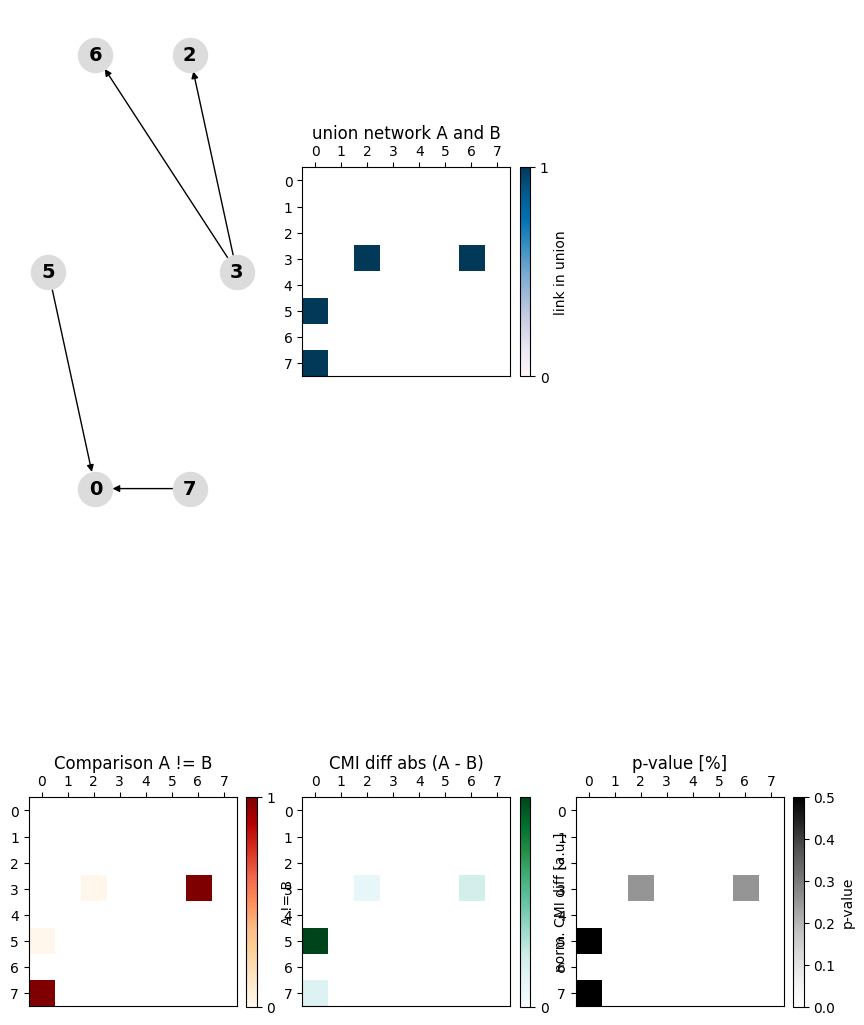

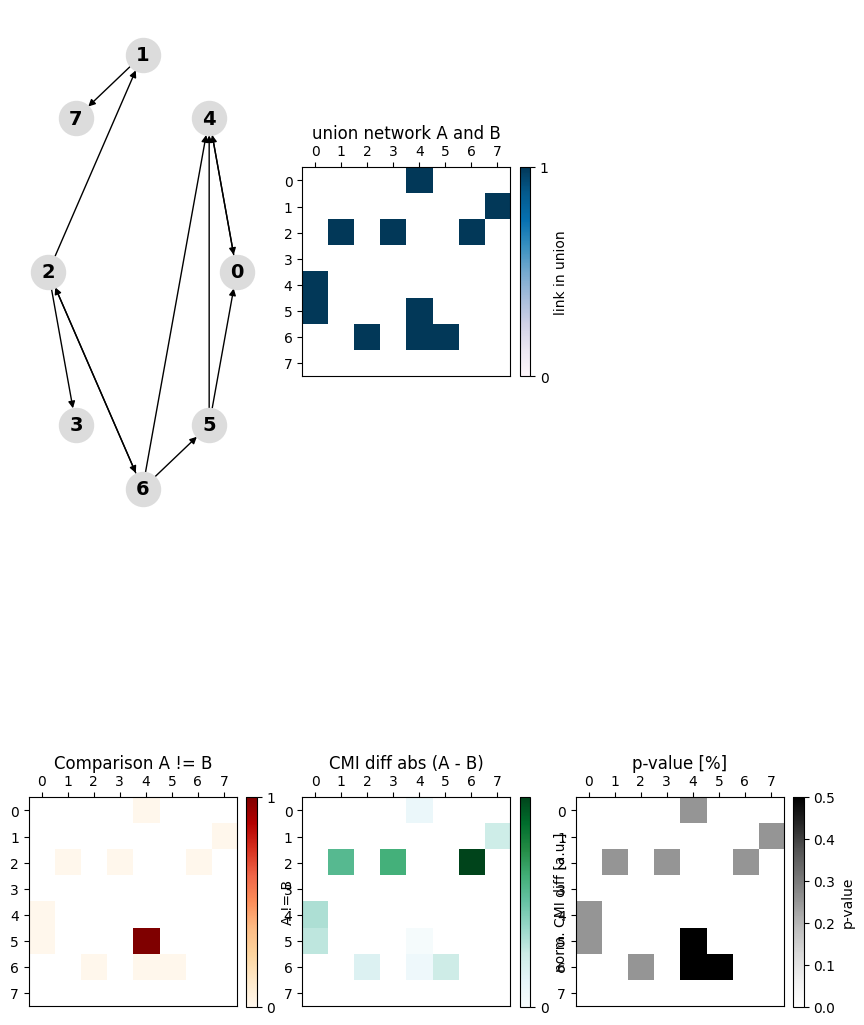

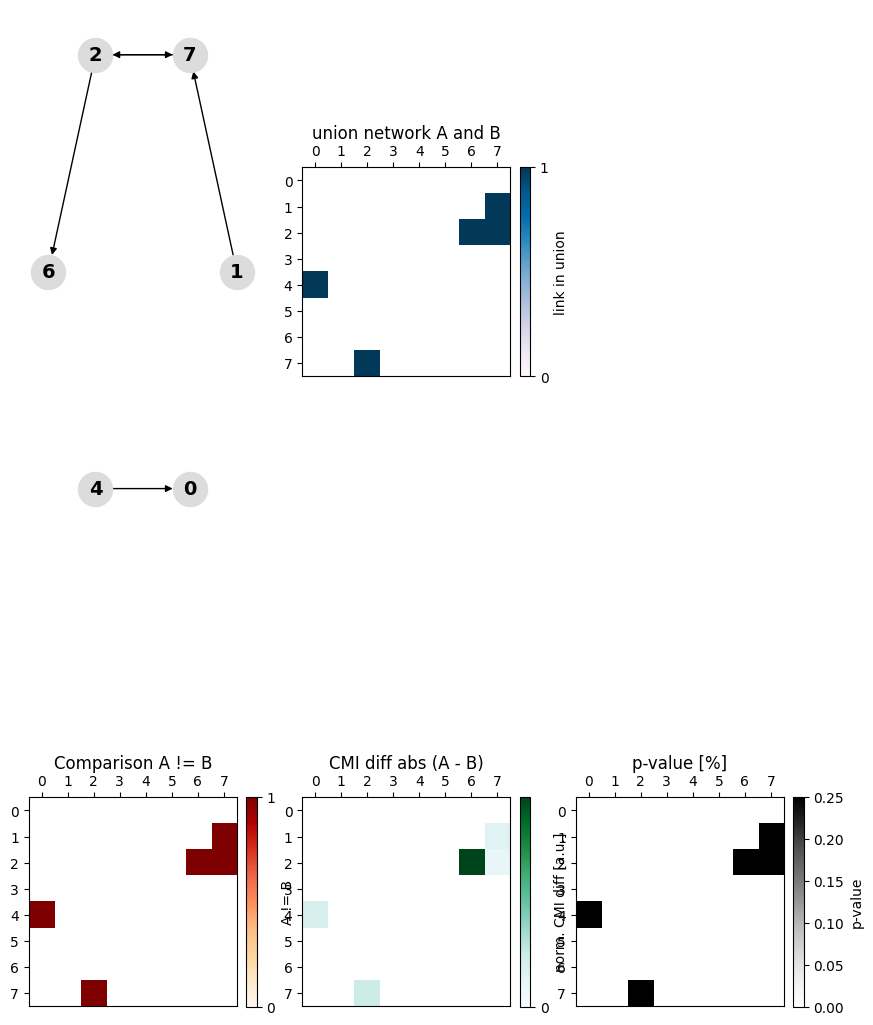

In [31]:
res_comp={}
for subj_name, subj_data in cond_data.items():
    current_data_dev=np.transpose(subj_data["dev"], (2, 1, 0)).astype(np.float32)[50*(0):50*(0+1),:,:]
    current_data_stand=np.transpose(subj_data["stand"], (2, 1, 0)).astype(np.float32)[50*(0):50*(0+1),:,:]
    data_dev=Data(current_data_dev, dim_order="spr", normalise=True)
    data_stand=Data(current_data_stand, dim_order="spr", normalise=True)
    
    res_comp[subj_name]=comp.compare_within(comp_settings, all_combined_results[subj_name]["dev"][0], all_combined_results[subj_name]["stand"][0], data_a=data_dev, data_b=data_stand) 
    plot_network_comparison(res_comp[subj_name]) 

{np.int64(0): array([0.00581498, 0.00093721]), np.int64(1): array([], dtype=float64), np.int64(2): array([0.00060467]), np.int64(3): array([], dtype=float64), np.int64(4): array([], dtype=float64), np.int64(5): array([], dtype=float64), np.int64(6): array([0.00122987]), np.int64(7): array([], dtype=float64)}
{np.int64(0): array([0.00581498, 0.00093721]), np.int64(1): array([], dtype=float64), np.int64(2): array([0.00060467]), np.int64(3): array([], dtype=float64), np.int64(4): array([], dtype=float64), np.int64(5): array([], dtype=float64), np.int64(6): array([0.00122987]), np.int64(7): array([], dtype=float64)}
{np.int64(0): array([0.00581498, 0.00093721]), np.int64(1): array([], dtype=float64), np.int64(2): array([0.00060467]), np.int64(3): array([], dtype=float64), np.int64(4): array([], dtype=float64), np.int64(5): array([], dtype=float64), np.int64(6): array([0.00122987]), np.int64(7): array([], dtype=float64)}
{np.int64(0): array([0.00581498, 0.00093721]), np.int64(1): array([], 

(<networkx.classes.digraph.DiGraph at 0x7f511e2823c0>,
 <Figure size 1000x1500 with 9 Axes>)

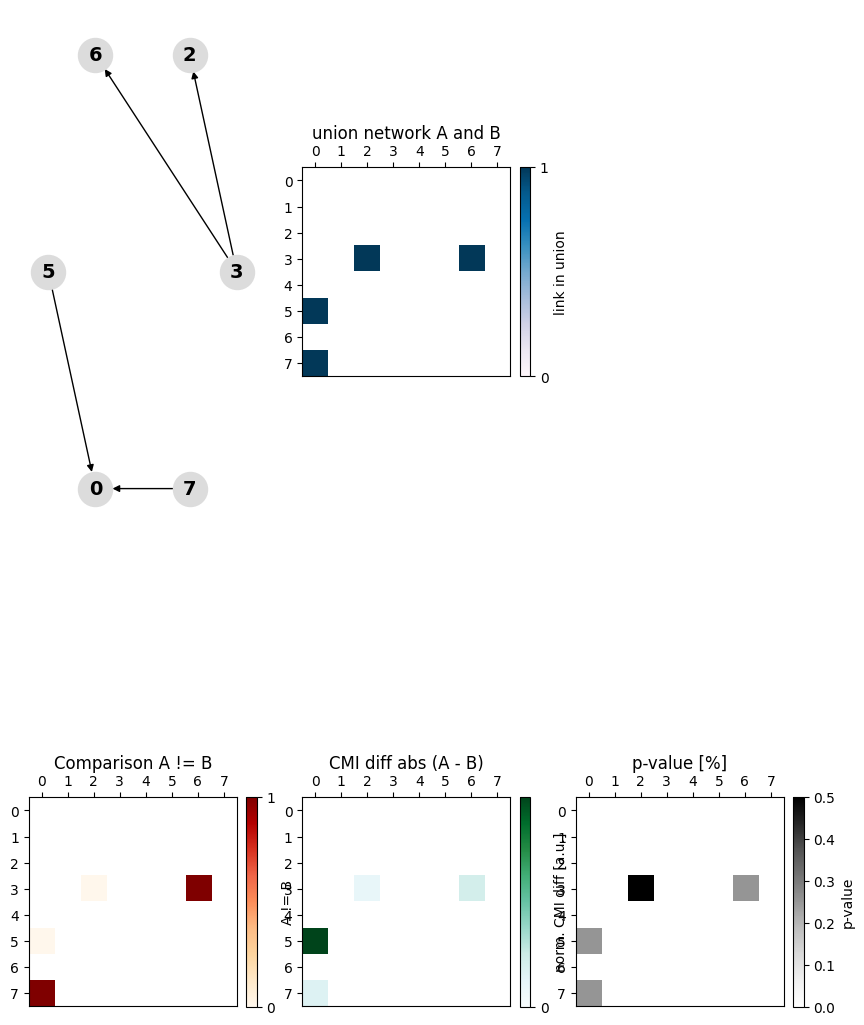

In [15]:
import matplotlib.patches as mpatches

In [99]:
all_te_vals = []

for subj in subjects:
    all_te_vals_subj = []
    for win in win_list:
        if win==0:
            for condition in ["dev", "stand"]:
                if win >= len(all_combined_results[subj][condition]):
                    continue
                for target in targets:
                
                    res = all_combined_results[subj][condition][win].get_single_target(target)
                    print(res)

{'sources_tested': [1, 2, 3, 4, 5, 6, 7], 'current_value': (0, 12), 'selected_vars_target': [(0, 1)], 'selected_vars_sources': [(7, np.int64(3))], 'selected_sources_pval': array([0.002]), 'selected_sources_te': array([0.0515741]), 'omnibus_te': 0.05157459489839811, 'omnibus_pval': 0.002, 'omnibus_sign': True, 'te': array([0.05157408])}
{'sources_tested': [0, 2, 3, 4, 5, 6, 7], 'current_value': (1, 12), 'selected_vars_target': [(1, 1)], 'selected_vars_sources': [], 'selected_sources_pval': None, 'selected_sources_te': None, 'omnibus_te': None, 'omnibus_pval': None, 'omnibus_sign': False, 'te': None}
{'sources_tested': [0, 1, 3, 4, 5, 6, 7], 'current_value': (2, 12), 'selected_vars_target': [(2, 1)], 'selected_vars_sources': [(3, np.int64(4))], 'selected_sources_pval': array([0.002]), 'selected_sources_te': array([0.03627793]), 'omnibus_te': 0.03627737192183411, 'omnibus_pval': 0.002, 'omnibus_sign': True, 'te': array([0.03627798])}
{'sources_tested': [0, 1, 2, 4, 5, 6, 7], 'current_valu

In [158]:
import csv
import numpy as np

max_te_vals = []

for subj in subjects:
    for win in win_list:
        if win != 0:
            continue
        for condition in ["dev", "stand"]:
            all_te_vals_subj = []
            for target in targets:
                try:
                    res = all_combined_results[subj][condition][win].get_single_target(target)
                    if not res["selected_vars_sources"]:
                        continue
                    for [source, source_lag], te_val in zip(res["selected_vars_sources"], res["selected_sources_te"]):
                        all_te_vals_subj.append([subj, condition, source, source_lag, te_val, target])
                except:
                    continue

            if all_te_vals_subj:
                arr = np.array(all_te_vals_subj)
                wheremax = np.argmax(arr[:, 4].astype(float))
                max_row = arr[wheremax, :]
                print(f"subj: {subj} {max_row}")
                max_te_vals.append(max_row.tolist())

# Save only max rows to CSV
csv_path = "te_results_max.csv"
with open(csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["subject", "condition", "source", "source_lag", "te_value", "target"])
    writer.writerows(max_te_vals)

print(f"Saved {len(max_te_vals)} rows to {csv_path}")

subj: Fr ['Fr' 'dev' '3' '8' '0.05308962824114283' '6']
subj: Fr ['Fr' 'stand' '3' '9' '0.046798918835097236' '6']
subj: Go ['Go' 'dev' '2' '9' '0.06585118664156275' '6']
subj: Go ['Go' 'stand' '2' '9' '0.07634649429390761' '6']
subj: Kr ['Kr' 'dev' '2' '8' '0.10792949242607985' '6']
subj: Kr ['Kr' 'stand' '2' '9' '0.09397180683169193' '6']
Saved 6 rows to te_results_max.csv


In [ ]:
all_te_vals = []

for subj in subjects:
    all_te_vals_subj = []
    for win in win_list:
        for condition in ["dev", "stand"]:
            if win >= len(all_combined_results[subj][condition]):
                continue
            for target in targets:
                try:
                    res = all_combined_results[subj][condition][win].get_single_target(target)
                    if not res["selected_vars_sources"]:
                        continue
                    for [source,source_lag], te_val in zip(res["selected_vars_sources"], res["selected_sources_te"]):
                        all_te_vals_subj.append([condition,source, source_lag, te_val])
                except:
                    continue

            
    all_te_vals.append(all_te_vals_subj)
fr_te=np.array(all_te_vals[0])[:,3].astype(float)
go_te=np.array(all_te_vals[1])[:,3].astype(float)
kr_te=np.array(all_te_vals[2])[:,3].astype(float)
print(f"Fr: TE range: {np.min(fr_te):.4f} – {np.max(fr_te):.4f}, mean: {np.mean(fr_te):.4f}, std: {np.std(fr_te):.4f}")
print(f"Go: TE range: {np.min(go_te):.4f} – {np.max(go_te):.4f}, mean: {np.mean(go_te):.4f}, std: {np.std(go_te):.4f}")
print(f"Kr: TE range: {np.min(kr_te):.4f} – {np.max(kr_te):.4f}, mean: {np.mean(kr_te):.4f}, std: {np.std(kr_te):.4f}")


subj: Fr, where max connection was at:2
subj: Fr, where max connection was at:2
subj: Fr, where max connection was at:2
subj: Go, where max connection was at:17
subj: Go, where max connection was at:17
subj: Go, where max connection was at:17
subj: Kr, where max connection was at:2
subj: Kr, where max connection was at:2
subj: Kr, where max connection was at:2
Fr: TE range: 0.0363 – 0.0531, mean: 0.0453, std: 0.0060
Go: TE range: 0.0242 – 0.0763, mean: 0.0465, std: 0.0154
Kr: TE range: 0.0341 – 0.1079, mean: 0.0683, std: 0.0253


In [ ]:
subject_info = {
    "Fr": {"line": Lines[1], "picks": picks_indices[0], "epochs": ep_stand_fr_analysis, "montage": ep_stand_fr},
    "Go": {"line": Lines[2], "picks": picks_indices[1], "epochs": ep_stand_go_analysis, "montage": ep_stand_go},
    "Kr": {"line": Lines[0], "picks": picks_indices[2], "epochs": ep_stand_kr_analysis, "montage": ep_stand_kr},
}


In [ ]:
for ix,subj in enumerate(subjects):
    te_min=0
    te_max=np.max(all_te_vals[ix])


    cmap = plt.get_cmap("plasma")
    norm = Normalize(vmin=te_min, vmax=te_max)
    info = subject_info[subj]
    ch_pos = info["montage"].get_montage()._get_ch_pos()
    x, y, _ = np.array(list(ch_pos.values())).T * 1000

    for win in win_list:
        if win >= len(all_combined_results[subj]["dev"]) or win >= len(all_combined_results[subj]["stand"]):
            continue
        if win != 0:
            continue

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        for ax, condition in zip(axes, ["dev", "stand"]):
            if info["line"] is not None:
                ax.imshow(info["line"])
           
            for spine in ax.spines.values():
                spine.set_visible(False)
            ax.set_title(condition.capitalize())
            ax.scatter(x, y, c="k", alpha=0.3, s=15)
            for target in targets:
                try:
                    res = all_combined_results[subj][condition][win].get_single_target(target)
                    if not res["selected_vars_sources"]:
                        continue
                    for [source,source_lag], te_val in zip(res["selected_vars_sources"], res["selected_sources_te"]):
                        
                        color = cmap(norm(te_val))
                        print(f"Subject: {subj}, Win: {win}, Cond: {condition}, Target: {target}, Source: {source}, TE: {te_val:.4f}, Lag: {source_lag}")
                        
                        dx = x[info["picks"][target]] - x[info["picks"][source]]
                        dy = y[info["picks"][target]] - y[info["picks"][source]]
                        angle = np.degrees(np.arctan2(dy, dx))

                        # If arrow points generally rightward, label above; leftward, label below
                        # This keeps the label on the outside of the arc
                        va = 'top' if -90 < angle <= 90 else 'bottom'
                        ha= "left" if -90 < angle <= 90 else "right"
                        
                        arr = mpatches.FancyArrowPatch(
                            (x[info["picks"][source]], y[info["picks"][source]]),
                            (x[info["picks"][target]], y[info["picks"][target]]),
                            arrowstyle='->',
                            mutation_scale=20,
                            color=color,
                            connectionstyle="arc3,rad=0.2",
                            lw=2,
                        )
                        ax.add_patch(arr)
                        ax.annotate(f"{source_lag*2}", (0.5, 0.5), xycoords=arr, 
                                    fontsize=8, color="black", ha='center', va=va,bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=color, alpha=0.7))
                except Exception as e:
                    print(f"Error — {subj}, win {win}, {condition}, target {target}: {e}")

            ax.scatter(x[info["picks"]], y[info["picks"]], c=[cmap(0)], s=100)
            for idx, pick in enumerate(info["picks"]):
                ax.annotate(f"{idx}", xy=(x[pick], y[pick]), fontsize=8, color='white', ha="center", va="center")
            ax.set(xticks=[], yticks=[])
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        fig.colorbar(sm, ax=axes, label="Transfer Entropy")
        fig.suptitle(f"{subj} | Window: {(win*100)-100} - {(win+1)*100-100} ms", fontsize=16)
        plt.savefig(f"{subj}_combined_win_{win:03d}.png", dpi=300, bbox_inches="tight")
        plt.close(fig)

Subject: Fr, Win: 0, Cond: dev, Target: 0, Source: 7, TE: 0.0516, Lag: 3
Subject: Fr, Win: 0, Cond: dev, Target: 2, Source: 3, TE: 0.0363, Lag: 4
Subject: Fr, Win: 0, Cond: dev, Target: 6, Source: 3, TE: 0.0531, Lag: 8
Subject: Fr, Win: 0, Cond: stand, Target: 0, Source: 5, TE: 0.0437, Lag: 9
Subject: Fr, Win: 0, Cond: stand, Target: 2, Source: 3, TE: 0.0401, Lag: 4
Subject: Fr, Win: 0, Cond: stand, Target: 6, Source: 3, TE: 0.0468, Lag: 9
Subject: Go, Win: 0, Cond: dev, Target: 0, Source: 4, TE: 0.0368, Lag: 9
Subject: Go, Win: 0, Cond: dev, Target: 1, Source: 2, TE: 0.0624, Lag: 6
Subject: Go, Win: 0, Cond: dev, Target: 2, Source: 6, TE: 0.0571, Lag: 9
Subject: Go, Win: 0, Cond: dev, Target: 3, Source: 2, TE: 0.0393, Lag: 6
Subject: Go, Win: 0, Cond: dev, Target: 4, Source: 6, TE: 0.0289, Lag: 1
Subject: Go, Win: 0, Cond: dev, Target: 4, Source: 0, TE: 0.0291, Lag: 9
Subject: Go, Win: 0, Cond: dev, Target: 5, Source: 6, TE: 0.0283, Lag: 3
Subject: Go, Win: 0, Cond: dev, Target: 6, So

___

## Calculate sTE

In [ ]:
te_settings = {
    "cmi_estimator": "JidtKraskovCMI",
    "max_lag_sources": 12, 
    "min_lag_sources": 1,
    "max_lag_target": 12,
    "tau_target": 4, 
    "fdr_correction": True,   
    "n_perm_max_stat": 200,
    "permute_in_time": True,
    "normalise": True,
    "verbose": False
}

spectral_settings = {'cmi_estimator': 'JidtKraskovCMI',
                    'verbose': False,
                    'n_scale': 5,
                    'wavelet': 'la8',  # or la16, mother wavelets
                    'alpha_spec': 0.05,
                    'permute_in_time_spec': True,
                    'perm_type_spec': 'block',
                    'block_size_spec': 1,
                    'spectral_analysis_type': 'both',
                    'fdr_corrected': True,
                    'parallel_surr': True,
                    'surr_type': 'spectr',  # or 'iaaft'
                    'n_jobs': 200,
                    'verb_parallel': 50,
                    'perm_range_spec': int(200),
                    'normalise': True}

In [ ]:

from idtxl.visualise_graph import plot_spectral_result


In [22]:

# Timing parameters
FS = 500  
WIN_SIZE_SAMP = 50  # 100 ms
STEP_SAMP = 50      # 20 ms (Smooth step)

task_list = []
tmp_files = []


In [ ]:
result_spectral={}
spectral_analysis = MultivariateSpectralTE()

In [ ]:

for subj_name, subj_data in cond_data.items():
    if subj_name == "Fr":
        te_settings["verbose"] = True
        spectral_settings["verbose"] = True
    else:
        te_settings["verbose"] = True
        spectral_settings["verbose"] = True
    if subj_name != "re":
        for cond_name, raw_arr in subj_data.items():
            # IDTxl 'spr' format: (samples, channels, repetitions)
            formatted_data = np.transpose(raw_arr, (2, 1, 0)).astype(np.float32)
            current_data=np.transpose(cond_data[subj_name][cond_name], (2, 1, 0)).astype(np.float32)
            for win_idx, res in enumerate(all_combined_results[subj_name][cond_name]):
                if win_idx==0:
                    window_slice = current_data[50*(win_idx):50*(win_idx+1),:,:]
                    data = Data(window_slice, dim_order="spr", normalise=True)
                    for (source,target,lag) in res.get_adjacency_matrix(weights='max_te_lag', fdr=False).get_edge_list():
                        print(target,source)
                        
                        result_spectral[(subj_name, cond_name, win_idx, target, source)] = spectral_analysis.analyse_single_target(
                            spectral_settings, data, all_combined_results[subj_name][cond_name][win_idx],sources=[source], target=target)
                    
                        fig=plot_spectral_result(result_spectral[(subj_name, cond_name, win_idx, target, source)], freq_rate=500)
                        fig.suptitle(f"{subj_name} | {cond_name} | Window: {win_idx*100}-{(win_idx+1)*100} ms | Target: {target} | Source: {source}", fontsize=12)
                        
                        fig.savefig(f"{subj_name}_{cond_name}_win_{win_idx*100}_{(win_idx+1)*100}_target_{target}_source_{source}.png", dpi=300, bbox_inches="tight")
                        plt.close(fig)
                                        
#save results_spectral with pickle
#with open("results_spectral.pkl", "wb") as f:
#    pickle.dump(result_spectral, f)

## Analyze saved sTE

In [32]:
fr_spectral_dict={
    "top_down":{
        "stand":{
            "source":3,
            "target":6
        },
        "dev":{
            "source":3,
            "target":6
        }
    },
    "bottom_up":{
        "stand":{
            "source":5,
            "target":0
        }
    }
    }
go_spectral_dict={
    "top_down":{
        "stand":{
            "source":2,
            "target":6
        },
        "dev":{
            "source":2,
            "target":6
        }
    },
    "bottom_up":{
        "dev":{
            "source":6,
            "target":2
        }
    }
    }
kr_spectral_dict={
    "top_down":{
        "stand":{
            "source":2,
            "target":6
        },
        "dev":{
            "source":2,
            "target":6 }
        },
    "bottom_up":{
        "stand":{
            "source":4,
            "target":0
        },
        "dev":{
            "source":4,
            "target":0
        }
    }
    }



In [ ]:
import csv
bands=["alpha","beta","gamma","high_gamma","high_gamma_2"][::-1]

alpha_threshold=0.05/5


['high_gamma_2', 'high_gamma', 'gamma', 'beta', 'alpha']

In [93]:

fr_res_spectral_dict = {}
csv_rows = []

for direction in fr_spectral_dict.keys():
    if direction == "top_down":
        for cond in fr_spectral_dict[direction].keys():
            source = fr_spectral_dict[direction][cond]["source"]
            target = fr_spectral_dict[direction][cond]["target"]
            file_name = f"result_Fr_{cond}_win_0_target_{target}_source_{source}.pkl"
            print(f"Loading {file_name}...")
            try:
                with open(f"/home/sgl/Masterthesis_Marmoset_MMN/spectral_results/{file_name}", 'rb') as f:
                    res = ConvertJDoubleUnpickler(f).load()
                print(f"fr: direction {direction}, condition {cond}, target {target}, source {source}")

                for band in range(5):
                    target_data = res.get_single_target(target=target)['source'][band]
                    pval = np.array(target_data['spec_pval']).flatten()
                    deltaO = np.round(np.array(target_data['deltaO']).flatten(), 3)
                    significant = pval < alpha_threshold
                    significant_text = "significant" if significant else "not significant"

                    print(
                        f"{bands[band]}: {significant_text} "
                        f"p-value = {pval}, deltaO = {deltaO}"
                    )

                    csv_rows.append({
                        "direction":   direction,
                        "condition":   cond,
                        "target":      target,
                        "source":      source,
                        "band":        bands[band],
                        "p_value":     pval[0] if pval.size == 1 else str(pval.tolist()),
                        "deltaO":      deltaO[0] if deltaO.size == 1 else str(deltaO.tolist()),
                        "significant": significant_text,
                    })

                fr_res_spectral_dict[(direction, cond)] = res

            except Exception as e:
                print(f"Error loading {e}")

output_csv = "fr_spectral_results.csv"
fieldnames = ["direction", "condition", "target", "source", "band",
              "p_value", "deltaO", "significant"]

with open(output_csv, "w", newline="") as csvfile:
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(csv_rows)

print(f"\nResults saved to '{output_csv}' ({len(csv_rows)} rows).")

Loading result_Fr_stand_win_0_target_6_source_3.pkl...
fr: direction top_down, condition stand, target 6, source 3
delta: not significant p-value = [0.235], deltaO = [0.003]
theta: not significant p-value = [0.135], deltaO = [0.004]
alpha: significant p-value = [0.005], deltaO = [0.016]
beta: not significant p-value = [0.43], deltaO = [0.001]
gamma: not significant p-value = [0.065], deltaO = [0.005]
Loading result_Fr_dev_win_0_target_6_source_3.pkl...
fr: direction top_down, condition dev, target 6, source 3
delta: not significant p-value = [0.145], deltaO = [0.004]
theta: not significant p-value = [0.23], deltaO = [0.003]
alpha: significant p-value = [0.005], deltaO = [0.022]
beta: not significant p-value = [0.585], deltaO = [-0.001]
gamma: not significant p-value = [0.075], deltaO = [0.006]

Results saved to 'fr_spectral_results.csv' (10 rows).


In [94]:

go_res_spectral_dict = {}
csv_rows = []

for direction in go_spectral_dict.keys():
    if direction == "top_down":
        for cond in go_spectral_dict[direction].keys():
            source = go_spectral_dict[direction][cond]["source"]
            target = go_spectral_dict[direction][cond]["target"]
            file_name = f"result_Go_{cond}_win_0_target_{target}_source_{source}.pkl"
            print(f"Loading {file_name}...")
            try:
                with open(f"/home/sgl/Masterthesis_Marmoset_MMN/spectral_results/{file_name}", 'rb') as f:
                    res = ConvertJDoubleUnpickler(f).load()
                print(f"go: direction {direction}, condition {cond}, target {target}, source {source}")

                for band in range(5):
                    target_data = res.get_single_target(target=target)['source'][band]
                    pval = np.array(target_data['spec_pval']).flatten()
                    deltaO = np.round(np.array(target_data['deltaO']).flatten(), 3)
                    significant = pval < alpha_threshold
                    significant_text = "significant" if significant else "not significant"

                    print(
                        f"{bands[band]}: {significant_text} "
                        f"p-value = {pval}, deltaO = {deltaO}"
                    )

                    csv_rows.append({
                        "direction":   direction,
                        "condition":   cond,
                        "target":      target,
                        "source":      source,
                        "band":        bands[band],
                        "p_value":     pval[0] if pval.size == 1 else str(pval.tolist()),
                        "deltaO":      deltaO[0] if deltaO.size == 1 else str(deltaO.tolist()),
                        "significant": significant_text,
                    })

                go_res_spectral_dict[(direction, cond)] = res

            except Exception as e:
                print(f"Error loading {e}")

output_csv = "go_spectral_results.csv"
fieldnames = ["direction", "condition", "target", "source", "band",
              "p_value", "deltaO", "significant"]

with open(output_csv, "w", newline="") as csvfile:
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(csv_rows)

print(f"\nResults saved to '{output_csv}' ({len(csv_rows)} rows).")

Loading result_Go_stand_win_0_target_6_source_2.pkl...
go: direction top_down, condition stand, target 6, source 2
delta: not significant p-value = [0.095], deltaO = [0.003]
theta: not significant p-value = [0.11], deltaO = [0.003]
alpha: not significant p-value = [0.885], deltaO = [-0.003]
beta: significant p-value = [0.005], deltaO = [0.037]
gamma: significant p-value = [0.005], deltaO = [0.032]
Loading result_Go_dev_win_0_target_6_source_2.pkl...
go: direction top_down, condition dev, target 6, source 2
delta: not significant p-value = [0.505], deltaO = [-0.]
theta: not significant p-value = [0.64], deltaO = [-0.001]
alpha: not significant p-value = [1.], deltaO = [-0.01]
beta: significant p-value = [0.005], deltaO = [0.027]
gamma: significant p-value = [0.005], deltaO = [0.026]

Results saved to 'go_spectral_results.csv' (10 rows).


In [ ]:

kr_res_spectral_dict = {}
csv_rows = []

for direction in kr_spectral_dict.keys():
    if direction == "top_down":
        for cond in kr_spectral_dict[direction].keys():
            source = kr_spectral_dict[direction][cond]["source"]
            target = kr_spectral_dict[direction][cond]["target"]
            file_name = f"result_Kr_{cond}_win_0_target_{target}_source_{source}.pkl"
            print(f"Loading {file_name}...")
            try:
                with open(f"/home/sgl/Masterthesis_Marmoset_MMN/spectral_results/{file_name}", 'rb') as f:
                    res = ConvertJDoubleUnpickler(f).load()
                print(f"kr: direction {direction}, condition {cond}, target {target}, source {source}")

                for band in range(5):
                    target_data = res.get_single_target(target=target)['source'][band]
                    pval = np.array(target_data['spec_pval']).flatten()
                    deltaO = np.round(np.array(target_data['deltaO']).flatten(), 3)
                    significant = pval < alpha_threshold
                    significant_text = "significant" if significant else "not significant"

                    print(
                        f"{bands[band]}: {significant_text} "
                        f"p-value = {pval}, deltaO = {deltaO}"
                    )

                    csv_rows.append({
                        "direction":   direction,
                        "condition":   cond,
                        "target":      target,
                        "source":      source,
                        "band":        bands[band],
                        "p_value":     pval[0] if pval.size == 1 else str(pval.tolist()),
                        "deltaO":      deltaO[0] if deltaO.size == 1 else str(deltaO.tolist()),
                        "significant": significant_text,
                    })

                kr_res_spectral_dict[(direction, cond)] = res

            except Exception as e:
                print(f"Error loading {e}")

output_csv = "kr_spectral_results.csv"
fieldnames = ["direction", "condition", "target", "source", "band",
              "p_value", "deltaO", "significant"]

with open(output_csv, "w", newline="") as csvfile:
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(csv_rows)

print(f"\nResults saved to '{output_csv}' ({len(csv_rows)} rows).")

Loading result_Kr_stand_win_0_target_6_source_2.pkl...
kr: direction top_down, condition stand, target 6, source 2
delta: not significant p-value = [0.84], deltaO = [-0.003]
theta: not significant p-value = [0.895], deltaO = [-0.003]
alpha: not significant p-value = [1.], deltaO = [-0.009]
beta: significant p-value = [0.005], deltaO = [0.019]
gamma: significant p-value = [0.005], deltaO = [0.052]
Loading result_Kr_dev_win_0_target_6_source_2.pkl...
kr: direction top_down, condition dev, target 6, source 2
delta: significant p-value = [0.015], deltaO = [0.004]
theta: not significant p-value = [0.06], deltaO = [0.004]
alpha: not significant p-value = [0.58], deltaO = [-0.]
beta: significant p-value = [0.005], deltaO = [0.032]
gamma: significant p-value = [0.005], deltaO = [0.064]

Results saved to 'kr_spectral_results.csv' (10 rows).


In [ ]:
# save each result in results_spectral to a separate file
for key, value in result_spectral.items():
    with open(f"result_{key[0]}_{key[1]}_win_{key[2]}_target_{key[3]}_source_{key[4]}.pkl", "wb") as f:
        pickle.dump(value, f)

In [ ]:

# Use the full epoch range to allow for sliding
cond_data = {
    "stand": ep_stand_fr_analysis.get_data(copy=False),
    "dev":   ep_dev_fr_analysis.get_data(copy=False)
}

for cond_name, raw_arr in cond_data.items():
    # IDTxl 'spr' format: (samples, channels, repetitions)
    formatted_data = np.transpose(raw_arr, (2, 1, 0)).astype(np.float32)
    


In [ ]:
for subject in all_combined_results:
    for condition in all_combined_results[subject]:
        for win_idx, res in enumerate(all_combined_results[subject][condition]):
            print(f"Subject: {subject}, Condition: {condition}, Window: {win_idx}")
            res.print_edge_list(weights='max_te_lag', fdr=False)

Subject: Fr, Condition: dev, Window: 0
	5 -> 0, max_te_lag: 8
Subject: Fr, Condition: dev, Window: 1
No significant links found in the network.
Subject: Fr, Condition: dev, Window: 2
No significant links found in the network.
Subject: Fr, Condition: stand, Window: 0
	1 -> 6, max_te_lag: 9
	2 -> 0, max_te_lag: 5
Subject: Fr, Condition: stand, Window: 1
No significant links found in the network.
Subject: Fr, Condition: stand, Window: 2
No significant links found in the network.
Subject: Go, Condition: dev, Window: 0
	1 -> 6, max_te_lag: 7
	3 -> 4, max_te_lag: 5
	5 -> 0, max_te_lag: 10
	6 -> 3, max_te_lag: 9
Subject: Go, Condition: dev, Window: 1
	1 -> 6, max_te_lag: 6
	6 -> 4, max_te_lag: 3
Subject: Go, Condition: dev, Window: 2
No significant links found in the network.
Subject: Go, Condition: stand, Window: 0
	1 -> 6, max_te_lag: 7
	5 -> 0, max_te_lag: 10
	6 -> 3, max_te_lag: 10
	6 -> 4, max_te_lag: 3
Subject: Go, Condition: stand, Window: 1
	1 -> 6, max_te_lag: 7
	6 -> 4, max_te_lag: 

In [ ]:
#iterateoverall
# Run spectral TE analysis on significant source from Multivariate TE.
spectral_analysis = MultivariateSpectralTE()
result_spectral = spectral_analysis.analyse_single_target(
    spectral_settings, data, all_combined_results["Fr"]["stand"][0],sources=[1], target=6)


plot_spectral_result(result_spectral, freq_rate=500)

source sign
[1]
source var
[(1, np.int64(9))]
Spectral analysis with source surrogates
Testing Scale n: 0
[1]

testing source 1
selected vars
[(1, np.int64(3)), (6, 11)]
conditional_set
[(6, 11)]
source_set
[(1, np.int64(3))]
current value
(6, 12)
selected sources
[(1, np.int64(3))]
spectral
[Parallel(n_jobs=40)]: Using backend LokyBackend with 40 concurrent workers.


Adding data with properties: 5 processes, 50 samples, 684 replications
overwriting existing data
Adding data with properties: 5 processes, 50 samples, 684 replications
overwriting existing data
Adding data with properties: 5 processes, 50 samples, 684 replications
overwriting existing data
[Parallel(n_jobs=40)]: Done   1 tasks      | elapsed:    2.1s
Adding data with properties: 5 processes, 50 samples, 684 replications
overwriting existing data
Adding data with properties: 5 processes, 50 samples, 684 replicationsAdding data with properties: 5 processes, 50 samples, 684 replications
overwriting existing data
Adding data with properties: 5 processes, 50 samples, 684 replications
overwriting existing data

overwriting existing data
Adding data with properties: 5 processes, 50 samples, 684 replications
overwriting existing data
Adding data with properties: 5 processes, 50 samples, 684 replications
overwriting existing data
Adding data with properties: 5 processes, 50 samples, 684 replica

In [ ]:

# Run spectral TE analysis on significant source from Multivariate TE.
spectral_analysis = MultivariateSpectralTE()
result_spectral = spectral_analysis.analyse_single_target(
    spectral_settings, data, all_combined_results["Fr"]["stand"][0],sources=[2], target=0)

plot_spectral_result(result_spectral, freq_rate=500)

source sign
[2]
source var
[(2, np.int64(5))]
Spectral analysis with source surrogates
Testing Scale n: 0
[2]

testing source 2
selected vars
[(2, np.int64(7)), (0, 11)]
conditional_set
[(0, 11)]
source_set
[(2, np.int64(7))]
current value
(0, 12)
selected sources
[(2, np.int64(7))]
spectral
[Parallel(n_jobs=40)]: Using backend LokyBackend with 40 concurrent workers.
Adding data with properties: 5 processes, 50 samples, 684 replications
overwriting existing data
[Parallel(n_jobs=40)]: Done   1 tasks      | elapsed:    1.3s
Adding data with properties: 5 processes, 50 samples, 684 replications
overwriting existing data
Adding data with properties: 5 processes, 50 samples, 684 replications
overwriting existing data
Adding data with properties: 5 processes, 50 samples, 684 replicationsAdding data with properties: 5 processes, 50 samples, 684 replications
overwriting existing data
Adding data with properties: 5 processes, 50 samples, 684 replications
overwriting existing data

overwriting 

In [ ]:

# Run spectral TE analysis on significant source from Multivariate TE.
spectral_analysis = MultivariateSpectralTE()
result_spectral = spectral_analysis.analyse_single_target(
    spectral_settings, data, all_combined_results["Fr"]["dev"][0],sources=[5], target=0)

source sign
[5]
source var
[(5, np.int64(8))]
Spectral analysis with source surrogates
Testing Scale n: 0
[5]

testing source 5
selected vars
[(5, np.int64(4)), (0, 11)]
conditional_set
[(0, 11)]
source_set
[(5, np.int64(4))]
current value
(0, 12)
selected sources
[(5, np.int64(4))]
spectral
[Parallel(n_jobs=40)]: Using backend LokyBackend with 40 concurrent workers.
Adding data with properties: 5 processes, 50 samples, 684 replications
overwriting existing data
[Parallel(n_jobs=40)]: Done   1 tasks      | elapsed:    1.3s
Adding data with properties: 5 processes, 50 samples, 684 replications
overwriting existing data
Adding data with properties: 5 processes, 50 samples, 684 replications
overwriting existing data
Adding data with properties: 5 processes, 50 samples, 684 replications
overwriting existing data
Adding data with properties: 5 processes, 50 samples, 684 replications
overwriting existing data
Adding data with properties: 5 processes, 50 samples, 684 replicationsAdding data w

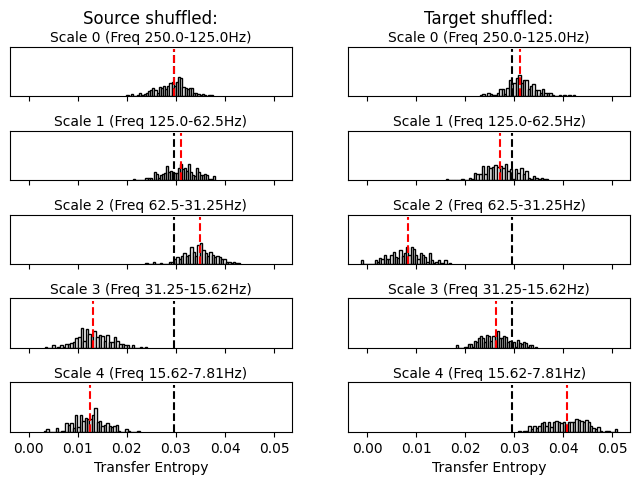

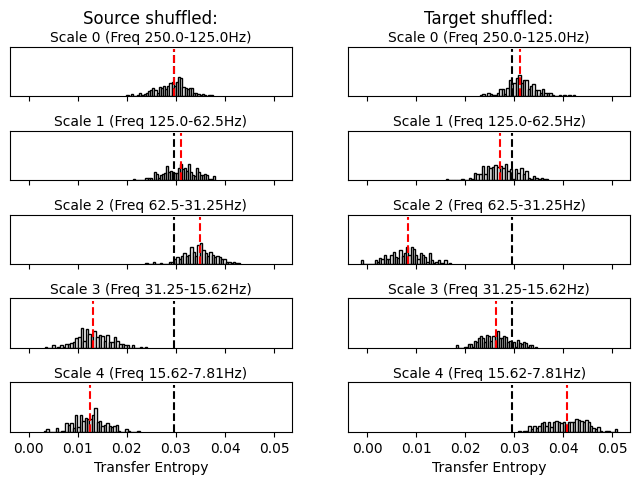

In [ ]:

from idtxl.visualise_graph import plot_spectral_result


plot_spectral_result(result_spectral, freq_rate=500)

In [ ]:
# Timing parameters
FS = 500  
WIN_SIZE_SAMP = 50  # 100 ms
STEP_SAMP = 25      # 20 ms (Smooth step)

task_list = []
tmp_files = []


win_starts = range(0, 250 - WIN_SIZE_SAMP + 1, STEP_SAMP)

for w_idx, t_start in enumerate(win_starts):
    t_end = t_start + WIN_SIZE_SAMP
    task_list.append(
        (w_idx, t_start, t_end))
